In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import (
    mannwhitneyu,
    chi2_contingency
)

from sklearn.preprocessing import LabelEncoder

In [3]:
folder = r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection"

train_provider_features = pd.read_csv(
    folder + r"\train_provider_features.csv"
)

In [4]:
print("Dataset Shape:", train_provider_features.shape)

Dataset Shape: (5410, 35)


In [5]:
display(train_provider_features.head())

,Provider,inpatient_claims,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_median_reimbursement,inpatient_unique_beneficiaries,avg_length_of_stay,max_length_of_stay,high_cost_inpatient_claims,high_cost_inpatient_rate,...,total_high_cost_claims,overall_high_cost_rate,inpatient_claim_mix,outpatient_claim_mix,inpatient_total_deductible,outpatient_total_deductible,total_deductible,avg_diagnosis_codes,avg_procedure_codes,PotentialFraud
0,PRV51001,5.0,97000.0,19400.000000,12000.0,5.0,5.000000,14.0,2.0,0.400000,...,7.0,0.280000,0.200000,0.800000,5340.0,0.0,5340.0,7.200000,0.600000,No
1,PRV51003,62.0,573000.0,9241.935484,7000.0,53.0,5.161290,27.0,3.0,0.048387,...,18.0,0.136364,0.469697,0.530303,66216.0,70.0,66286.0,8.112903,0.774194,Yes
2,PRV51007,3.0,19000.0,6333.333333,6000.0,3.0,5.333333,7.0,0.0,0.000000,...,3.0,0.041667,0.041667,0.958333,3204.0,60.0,3264.0,7.333333,0.333333,No
3,PRV51008,2.0,25000.0,12500.000000,12500.0,2.0,4.000000,5.0,1.0,0.500000,...,6.0,0.139535,0.046512,0.953488,2136.0,180.0,2316.0,7.500000,1.000000,No
4,PRV51011,1.0,5000.0,5000.000000,5000.0,1.0,5.000000,5.0,0.0,0.000000,...,6.0,0.103448,0.017241,0.982759,1068.0,300.0,1368.0,8.000000,0.000000,No


In [6]:
print(train_provider_features.columns.tolist())

['Provider', 'inpatient_claims', 'inpatient_total_reimbursement', 'inpatient_avg_reimbursement', 'inpatient_median_reimbursement', 'inpatient_unique_beneficiaries', 'avg_length_of_stay', 'max_length_of_stay', 'high_cost_inpatient_claims', 'high_cost_inpatient_rate', 'outpatient_claims', 'outpatient_total_reimbursement', 'outpatient_avg_reimbursement', 'outpatient_median_reimbursement', 'outpatient_unique_beneficiaries', 'high_cost_outpatient_claims', 'high_cost_outpatient_rate', 'total_claims', 'total_reimbursement', 'avg_reimbursement_per_claim', 'total_unique_beneficiaries_x', 'total_unique_beneficiaries_y', 'total_unique_beneficiaries', 'claims_per_beneficiary', 'reimbursement_per_beneficiary', 'total_high_cost_claims', 'overall_high_cost_rate', 'inpatient_claim_mix', 'outpatient_claim_mix', 'inpatient_total_deductible', 'outpatient_total_deductible', 'total_deductible', 'avg_diagnosis_codes', 'avg_procedure_codes', 'PotentialFraud']


In [7]:
print(
    train_provider_features["PotentialFraud"]
    .value_counts(dropna=False)
)

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


In [8]:
print(
    train_provider_features["PotentialFraud"]
    .unique()
)

['No' 'Yes']


# How Many Providers Are Fraudulent?

In [9]:
fraud_counts = (
    train_provider_features["PotentialFraud"]
    .value_counts()
)

print(fraud_counts)

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


In [10]:
# Calculate percentage

fraud_percentage = (
    train_provider_features["PotentialFraud"]
    .value_counts(normalize=True)
    * 100
)

print(fraud_percentage.round(2))


PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64


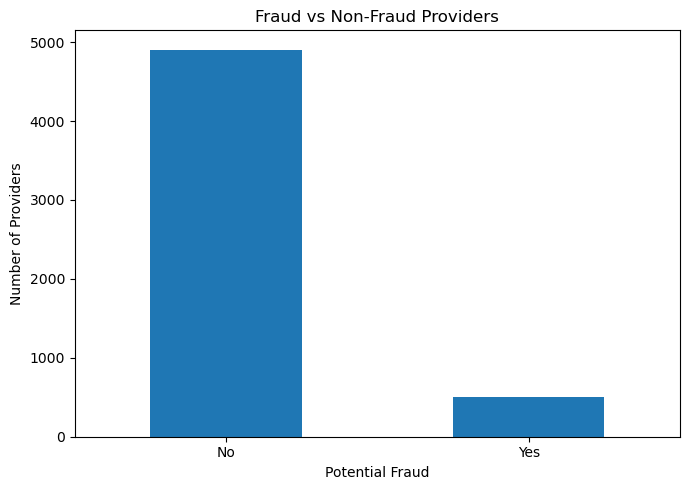

In [11]:
#Visualization

plt.figure(figsize=(7, 5))

fraud_counts.plot(
    kind="bar"
)

plt.title("Fraud vs Non-Fraud Providers")
plt.xlabel("Potential Fraud")
plt.ylabel("Number of Providers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
Answer

The Train dataset contains both potentially fraudulent and non-fraudulent providers. 
Fraudulent providers represent a minority of the provider population, indicating that the dataset is imbalanced.
This imbalance is important because fraud analysis should focus on identifying behavioral differences rather than simply relying on the majority class.

# Is the Fraud Dataset Imbalanced?

In [12]:
fraud_distribution = (
    train_provider_features[
        "PotentialFraud"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(fraud_distribution)

PotentialFraud
No     90.65
Yes     9.35
Name: proportion, dtype: float64

In [13]:
# Create a summary table

fraud_summary = pd.DataFrame({
    "Provider_Status": fraud_distribution.index,
    "Percentage": fraud_distribution.values
})

display(fraud_summary)

,Provider_Status,Percentage
0,No,90.65
1,Yes,9.35


In [ ]:
Why this matters

If fraudulent providers are much fewer than non-fraudulent providers, then:

Accuracy alone is not enough.
We need behavioral metrics.
We should compare distributions.
Statistical tests become useful.
Risk scoring should prioritize suspicious providers.

# Prepare Fraud Groups

In [14]:
train_provider_features["fraud_flag"] = (
    train_provider_features["PotentialFraud"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0
    })
)

In [15]:
# Check

print(
    train_provider_features["fraud_flag"]
    .value_counts(dropna=False)
)

fraud_flag
0    4904
1     506
Name: count, dtype: int64


In [16]:
print(
    "Missing fraud labels:",
    train_provider_features["fraud_flag"].isna().sum()
)

Missing fraud labels: 0


# Do Fraudulent Providers Have More Claims?

In [17]:
# Calculate group statistics

claim_comparison = (
    train_provider_features
    .groupby("PotentialFraud")["total_claims"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(claim_comparison)

,count,mean,median,min,max
PotentialFraud,,,,,
No,1298,93.822804,51.0,2.0,1245.0
Yes,396,340.106061,157.0,8.0,3436.0


<Figure size 800x500 with 0 Axes>

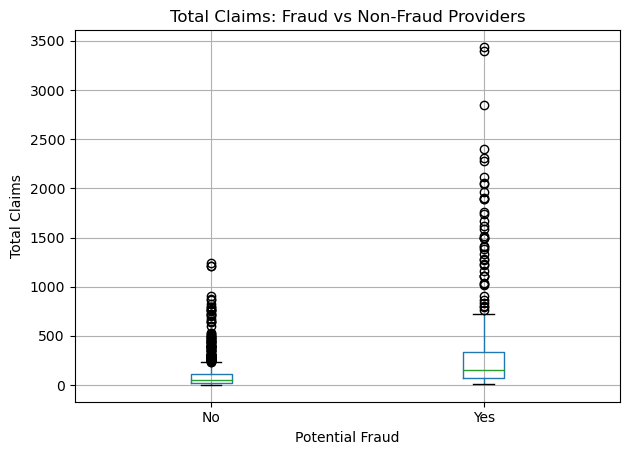

In [18]:
# Visualization


plt.figure(figsize=(8, 5))

train_provider_features.boxplot(
    column="total_claims",
    by="PotentialFraud"
)

plt.title("Total Claims: Fraud vs Non-Fraud Providers")
plt.suptitle("")
plt.xlabel("Potential Fraud")
plt.ylabel("Total Claims")

plt.tight_layout()
plt.show()

In [19]:
# Statistical Test

# Fraud datasets are usually skewed, so use Mann–Whitney U rather than assuming a normal distribution.

fraud_claims = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 1,
    "total_claims"
].dropna()

nonfraud_claims = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 0,
    "total_claims"
].dropna()

stat, p_value = mannwhitneyu(
    fraud_claims,
    nonfraud_claims,
    alternative="two-sided"
)

print("Mann-Whitney U Statistic:", stat)
print("P-value:", p_value)

Mann-Whitney U Statistic: 393852.5
P-value: 4.797807898192787e-58


In [20]:
# Interpretation



if p_value < 0.05:
    print("Statistically significant difference.")
else:
    print("No statistically significant difference.")

Statistically significant difference.


In [ ]:
Answer

I compared claim volumes between potentially fraudulent and non-fraudulent providers using the Mann–Whitney U test because provider claim counts are highly skewed.
A p-value below 0.05 would indicate that the claim-volume distributions differ significantly between the two groups.

# Do Fraudulent Providers Have Higher

In [21]:
reimbursement_comparison = (
    train_provider_features
    .groupby("PotentialFraud")[
        "total_reimbursement"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(reimbursement_comparison)

,count,mean,median,min,max
PotentialFraud,,,,,
No,1298,131571.155624,79595.0,1450.0,1311040.0
Yes,396,660214.090909,416305.0,26410.0,5996050.0


<Figure size 800x500 with 0 Axes>

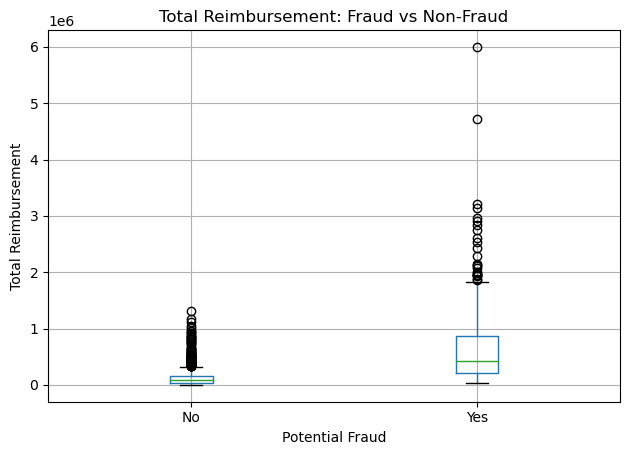

In [22]:
# Visualization:

plt.figure(figsize=(8, 5))

train_provider_features.boxplot(
    column="total_reimbursement",
    by="PotentialFraud"
)

plt.title(
    "Total Reimbursement: Fraud vs Non-Fraud"
)

plt.suptitle("")
plt.xlabel("Potential Fraud")
plt.ylabel("Total Reimbursement")

plt.tight_layout()
plt.show()


In [23]:
# Statistical test:

fraud_reimbursement = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 1,
    "total_reimbursement"
].dropna()

nonfraud_reimbursement = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 0,
    "total_reimbursement"
].dropna()

stat, p_value = mannwhitneyu(
    fraud_reimbursement,
    nonfraud_reimbursement,
    alternative="two-sided"
)

print("P-value:", p_value)


P-value: 1.4329913067452228e-112


# Do Fraudulent Providers Have Higher Average Claim Amounts?

In [24]:
avg_claim_comparison = (
    train_provider_features
    .groupby("PotentialFraud")[
        "avg_reimbursement_per_claim"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(avg_claim_comparison)

,count,mean,median,min,max
PotentialFraud,,,,,
No,4904,582.192940,0.000000,0.0,16300.000000
Yes,506,2755.927867,1933.977369,0.0,12575.172414


<Figure size 800x500 with 0 Axes>

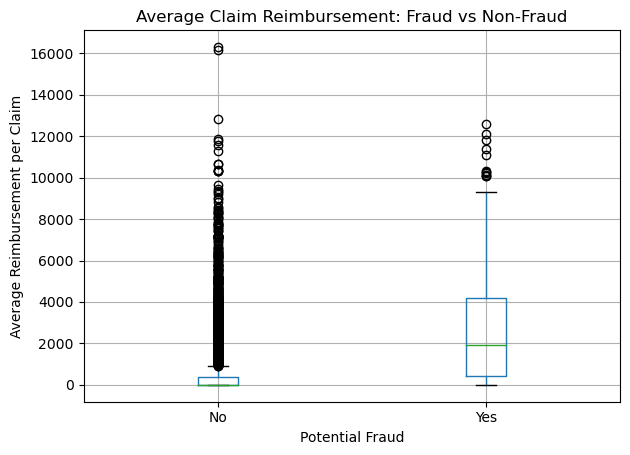

In [25]:
# Visualization


plt.figure(figsize=(8, 5))

train_provider_features.boxplot(
    column="avg_reimbursement_per_claim",
    by="PotentialFraud"
)

plt.title(
    "Average Claim Reimbursement: Fraud vs Non-Fraud"
)

plt.suptitle("")
plt.xlabel("Potential Fraud")
plt.ylabel("Average Reimbursement per Claim")

plt.tight_layout()
plt.show()

In [26]:
# Statistical test:

fraud_avg_claim = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 1,
    "avg_reimbursement_per_claim"
].dropna()

nonfraud_avg_claim = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 0,
    "avg_reimbursement_per_claim"
].dropna()

stat, p_value = mannwhitneyu(
    fraud_avg_claim,
    nonfraud_avg_claim,
    alternative="two-sided"
)

print("P-value:", p_value)

P-value: 3.8096021324957575e-153


# Do Fraudulent Providers Have More Beneficiaries?

In [27]:
beneficiary_comparison = (
    train_provider_features
    .groupby("PotentialFraud")[
        "total_unique_beneficiaries"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(beneficiary_comparison)

,count,mean,median,min,max
PotentialFraud,,,,,
No,4904,49.110318,22.0,1,807
Yes,506,242.021739,117.0,1,2857


In [28]:
# Test:

fraud_beneficiaries = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 1,
    "total_unique_beneficiaries"
].dropna()

nonfraud_beneficiaries = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 0,
    "total_unique_beneficiaries"
].dropna()

stat, p_value = mannwhitneyu(
    fraud_beneficiaries,
    nonfraud_beneficiaries,
    alternative="two-sided"
)

print("P-value:", p_value)

P-value: 1.1943733260968987e-124


# Do Fraudulent Providers Have Higher Claims per Beneficiary?

In [29]:
utilization_comparison = (
    train_provider_features
    .groupby("PotentialFraud")[
        "claims_per_beneficiary"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(utilization_comparison)

,count,mean,median,min,max
PotentialFraud,,,,,
No,4904,0.335029,0.000000,0.0,4.285714
Yes,506,1.110259,1.122103,0.0,3.347107


<Figure size 800x500 with 0 Axes>

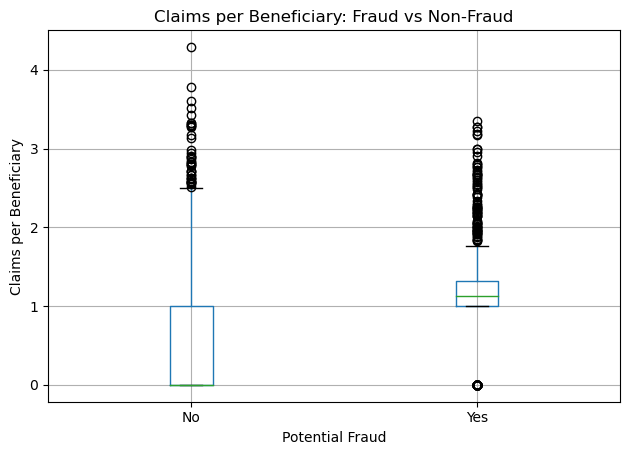

In [31]:
# Visualization:

plt.figure(figsize=(8, 5))

train_provider_features.boxplot(
    column="claims_per_beneficiary",
    by="PotentialFraud"
)

plt.title(
    "Claims per Beneficiary: Fraud vs Non-Fraud"
)

plt.suptitle("")
plt.xlabel("Potential Fraud")
plt.ylabel("Claims per Beneficiary")

plt.tight_layout()
plt.show()

In [32]:
# Statistical test:

fraud_utilization = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 1,
    "claims_per_beneficiary"
].dropna()

nonfraud_utilization = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 0,
    "claims_per_beneficiary"
].dropna()

stat, p_value = mannwhitneyu(
    fraud_utilization,
    nonfraud_utilization,
    alternative="two-sided"
)

print("P-value:", p_value)

P-value: 3.1333999458228926e-148


# Do Fraudulent Providers Have More High-Cost Claims?

In [33]:
high_cost_comparison = (
    train_provider_features
    .groupby("PotentialFraud")[
        "overall_high_cost_rate"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(high_cost_comparison)

,count,mean,median,min,max
PotentialFraud,,,,,
No,4904,0.027219,0.000000,0.0,0.500000
Yes,506,0.085539,0.099837,0.0,0.277778


In [34]:
# Statistical test:

fraud_high_cost = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 1,
    "overall_high_cost_rate"
].dropna()

nonfraud_high_cost = train_provider_features.loc[
    train_provider_features["fraud_flag"] == 0,
    "overall_high_cost_rate"
].dropna()

stat, p_value = mannwhitneyu(
    fraud_high_cost,
    nonfraud_high_cost,
    alternative="two-sided"
)

print("P-value:", p_value)

P-value: 2.1431944228845166e-136


# Which Features Statistically Differentiate Fraud?

In [35]:
analysis_features = [
    "total_claims",
    "total_reimbursement",
    "avg_reimbursement_per_claim",
    "total_unique_beneficiaries",
    "claims_per_beneficiary",
    "reimbursement_per_beneficiary",
    "overall_high_cost_rate",
    "inpatient_claim_mix",
    "outpatient_claim_mix",
    "avg_length_of_stay",
    "long_stay_rate",
    "avg_diagnosis_codes",
    "avg_procedure_codes",
    "total_deductible"
]

In [41]:
statistical_results = []

for feature in analysis_features:

    fraud_group = train_provider_features.loc[
        train_provider_features["fraud_flag"] == 1,
        feature
    ].dropna()

    nonfraud_group = train_provider_features.loc[
        train_provider_features["fraud_flag"] == 0,
        feature
    ].dropna()

    if len(fraud_group) > 0 and len(nonfraud_group) > 0:

        statistic, p_value = mannwhitneyu(
            fraud_group,
            nonfraud_group,
            alternative="two-sided"
        )

        statistical_results.append({
            "Feature": feature,
            "Fraud_Median": fraud_group.median(),
            "NonFraud_Median": nonfraud_group.median(),
            "Median_Difference": (
                fraud_group.median()
                - nonfraud_group.median()
            ),
            "P_Value": p_value
        })

In [42]:
# Create dataframe

statistical_results_df = pd.DataFrame(
    statistical_results
)

In [43]:
# Sort by p-value:

statistical_results_df = (
    statistical_results_df
    .sort_values("P_Value")
    .reset_index(drop=True)
)

In [44]:
# Display:

display(statistical_results_df)

,Feature,Fraud_Median,NonFraud_Median,Median_Difference,P_Value
0,total_deductible,26359.000000,200.000000,26159.000000,5.033816e-212
1,reimbursement_per_beneficiary,2718.153290,0.000000,2718.153290,7.311625e-164
2,avg_reimbursement_per_claim,1933.977369,0.000000,1933.977369,3.809602e-153
3,claims_per_beneficiary,1.122103,0.000000,1.122103,3.133400e-148
4,inpatient_claim_mix,0.151895,0.000000,0.151895,5.825196e-147
5,overall_high_cost_rate,0.099837,0.000000,0.099837,2.143194e-136
6,total_unique_beneficiaries,117.000000,22.000000,95.000000,1.194373e-124
7,total_reimbursement,416305.000000,79595.000000,336710.000000,1.432991e-112
8,outpatient_claim_mix,0.649258,0.000000,0.649258,3.810438e-97
9,total_claims,157.000000,51.000000,106.000000,4.797808e-58


# Identify Statistically Significant Features

In [46]:
significant_features = (
    statistical_results_df[
        statistical_results_df["P_Value"] < 0.05
    ]
)

display(significant_features)

,Feature,Fraud_Median,NonFraud_Median,Median_Difference,P_Value
0,total_deductible,26359.000000,200.000000,26159.000000,5.033816e-212
1,reimbursement_per_beneficiary,2718.153290,0.000000,2718.153290,7.311625e-164
2,avg_reimbursement_per_claim,1933.977369,0.000000,1933.977369,3.809602e-153
3,claims_per_beneficiary,1.122103,0.000000,1.122103,3.133400e-148
4,inpatient_claim_mix,0.151895,0.000000,0.151895,5.825196e-147
5,overall_high_cost_rate,0.099837,0.000000,0.099837,2.143194e-136
6,total_unique_beneficiaries,117.000000,22.000000,95.000000,1.194373e-124
7,total_reimbursement,416305.000000,79595.000000,336710.000000,1.432991e-112
8,outpatient_claim_mix,0.649258,0.000000,0.649258,3.810438e-97
9,total_claims,157.000000,51.000000,106.000000,4.797808e-58


In [47]:
print(
    "Number of statistically significant features:",
    len(significant_features)
)

Number of statistically significant features: 13


# Rank the Strongest Fraud Indicators

In [49]:
statistical_results_df[
    "Significance"
] = np.where(
    statistical_results_df["P_Value"] < 0.05,
    "Significant",
    "Not Significant"
)

In [50]:
display(
    statistical_results_df.head(10)
)

,Feature,Fraud_Median,NonFraud_Median,Median_Difference,P_Value,Significance
0,total_deductible,26359.000000,200.0,26159.000000,5.033816e-212,Significant
1,reimbursement_per_beneficiary,2718.153290,0.0,2718.153290,7.311625e-164,Significant
2,avg_reimbursement_per_claim,1933.977369,0.0,1933.977369,3.809602e-153,Significant
3,claims_per_beneficiary,1.122103,0.0,1.122103,3.133400e-148,Significant
4,inpatient_claim_mix,0.151895,0.0,0.151895,5.825196e-147,Significant
5,overall_high_cost_rate,0.099837,0.0,0.099837,2.143194e-136,Significant
6,total_unique_beneficiaries,117.000000,22.0,95.000000,1.194373e-124,Significant
7,total_reimbursement,416305.000000,79595.0,336710.000000,1.432991e-112,Significant
8,outpatient_claim_mix,0.649258,0.0,0.649258,3.810438e-97,Significant
9,total_claims,157.000000,51.0,106.000000,4.797808e-58,Significant


# Fraud vs Non-Fraud Feature Summary

In [51]:
fraud_feature_summary = (
    train_provider_features
    .groupby("PotentialFraud")[
        analysis_features
    ]
    .median()
    .T
)

display(fraud_feature_summary)

PotentialFraud,No,Yes
total_claims,51.000000,157.000000
total_reimbursement,79595.000000,416305.000000
avg_reimbursement_per_claim,0.000000,1933.977369
total_unique_beneficiaries,22.000000,117.000000
claims_per_beneficiary,0.000000,1.122103
reimbursement_per_beneficiary,0.000000,2718.153290
overall_high_cost_rate,0.000000,0.099837
inpatient_claim_mix,0.000000,0.151895
outpatient_claim_mix,0.000000,0.649258
avg_length_of_stay,5.000000,5.810004


# Create a Relative Difference Table

In [52]:
fraud_medians = (
    train_provider_features[
        train_provider_features["fraud_flag"] == 1
    ][analysis_features]
    .median()
)

nonfraud_medians = (
    train_provider_features[
        train_provider_features["fraud_flag"] == 0
    ][analysis_features]
    .median()
)

comparison_table = pd.DataFrame({
    "Fraud_Median": fraud_medians,
    "NonFraud_Median": nonfraud_medians
})

comparison_table["Difference_%"] = (
    (
        comparison_table["Fraud_Median"]
        -
        comparison_table["NonFraud_Median"]
    )
    /
    comparison_table["NonFraud_Median"].replace(0, np.nan)
    * 100
)

comparison_table = (
    comparison_table
    .replace([np.inf, -np.inf], np.nan)
    .sort_values(
        "Difference_%",
        ascending=False
    )
)

display(comparison_table)

,Fraud_Median,NonFraud_Median,Difference_%
total_deductible,26359.000000,200.000000,13079.500000
total_unique_beneficiaries,117.000000,22.000000,431.818182
total_reimbursement,416305.000000,79595.000000,423.029085
total_claims,157.000000,51.000000,207.843137
avg_length_of_stay,5.810004,5.000000,16.200077
avg_procedure_codes,0.733046,0.714286,2.626437
avg_diagnosis_codes,8.097002,8.200000,-1.256076
avg_reimbursement_per_claim,1933.977369,0.000000,NaN
claims_per_beneficiary,1.122103,0.000000,NaN
reimbursement_per_beneficiary,2718.153290,0.000000,NaN


# Final Fraud Pattern Summary

In [53]:
print("========== FRAUD PATTERN VALIDATION ==========")

print(
    "Total Providers:",
    train_provider_features["Provider"].nunique()
)

print(
    "Fraudulent Providers:",
    (
        train_provider_features["fraud_flag"] == 1
    ).sum()
)

print(
    "Non-Fraud Providers:",
    (
        train_provider_features["fraud_flag"] == 0
    ).sum()
)

print(
    "Significant Features:",
    len(significant_features)
)

========== FRAUD PATTERN VALIDATION ==========
Total Providers: 5410
Fraudulent Providers: 506
Non-Fraud Providers: 4904
Significant Features: 13


# Save Statistical Results

In [54]:
statistical_results_df.to_csv(
    folder + r"\train_fraud_statistical_results.csv",
    index=False
)

In [56]:
comparison_table.to_csv(
    folder + r"\train_fraud_feature_comparison.csv"
)